# Antenna Fault Detection & Diagnostics

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

## Data Loading

In [2]:
df = pd.read_csv(r"C:\Users\chara\Downloads\antenna_dataset.csv")

In [3]:
# Printing first 5 rows
df.head()

,S11 (dB),VSWR,Gain (dBi),Eff (%),BW (MHz),Z_Real (Ohms),Z_Imag (Ohms),Status,Fault_Type
0,0.054466,-0.631356,0.422205,0.361451,0.904843,-0.038140,0.519633,1,1
1,0.115230,-0.329512,0.397559,0.109627,0.698747,-0.304900,-0.689372,1,4
2,1.071530,0.836072,-1.270175,-1.140808,-1.238553,-1.475135,2.461611,1,2
3,0.961577,2.693575,-2.465521,-1.171201,-1.114896,-1.195323,1.660919,1,2
4,0.897920,0.654965,-0.921019,-0.915035,-1.320991,-1.194915,2.287132,1,2


In [4]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S11 (dB)       1500 non-null   float64
 1   VSWR           1500 non-null   float64
 2   Gain (dBi)     1500 non-null   float64
 3   Eff (%)        1500 non-null   float64
 4   BW (MHz)       1500 non-null   float64
 5   Z_Real (Ohms)  1500 non-null   float64
 6   Z_Imag (Ohms)  1500 non-null   float64
 7   Status         1500 non-null   int64  
 8   Fault_Type     1500 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 105.6 KB


In [5]:
# Statistical Measures of data
df.describe()

,S11 (dB),VSWR,Gain (dBi),Eff (%),BW (MHz),Z_Real (Ohms),Z_Imag (Ohms),Status,Fault_Type
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1500.000000,1500.000000
mean,-3.434290e-17,4.618528e-17,-5.447494e-17,-2.131628e-16,-7.105427e-17,2.202682e-16,2.131628e-17,0.833333,2.500000
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,0.372802,1.708395
min,-2.947536e+00,-1.021432e+00,-2.506598e+00,-1.761684e+00,-1.898060e+00,-1.603620e+00,-1.243483e+00,0.000000,0.000000
25%,-2.826261e-01,-6.731499e-01,-6.632596e-01,-7.978067e-01,-8.675808e-01,-7.094243e-01,-6.967417e-01,1.000000,1.000000
50%,1.492282e-01,-4.177432e-01,2.147652e-01,-4.233534e-02,1.422885e-01,-9.544859e-02,-2.691083e-01,1.000000,2.500000
75%,7.854358e-01,5.202960e-01,6.645604e-01,5.872241e-01,6.987471e-01,2.587015e-01,2.213655e-01,1.000000,4.000000
max,1.236460e+00,3.120801e+00,1.597012e+00,2.054749e+00,1.811664e+00,2.878678e+00,2.932466e+00,1.000000,5.000000


## Data Cleaning

In [6]:
#Outlier Detection and Removal using IQR
features = ['S11 (dB)', 'VSWR', 'Gain (dBi)', 'Eff (%)', 'BW (MHz)', 'Z_Real (Ohms)', 'Z_Imag (Ohms)']
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)
IQR = Q3 - Q1
df_cleaned = df[~((df[features] < (Q1 - 1.5 * IQR)) | (df[features] > (Q3 + 1.5 * IQR))).any(axis=1)].copy()
df_cleaned.shape

(1036, 9)

## Exploratory Data Analysis (EDA)

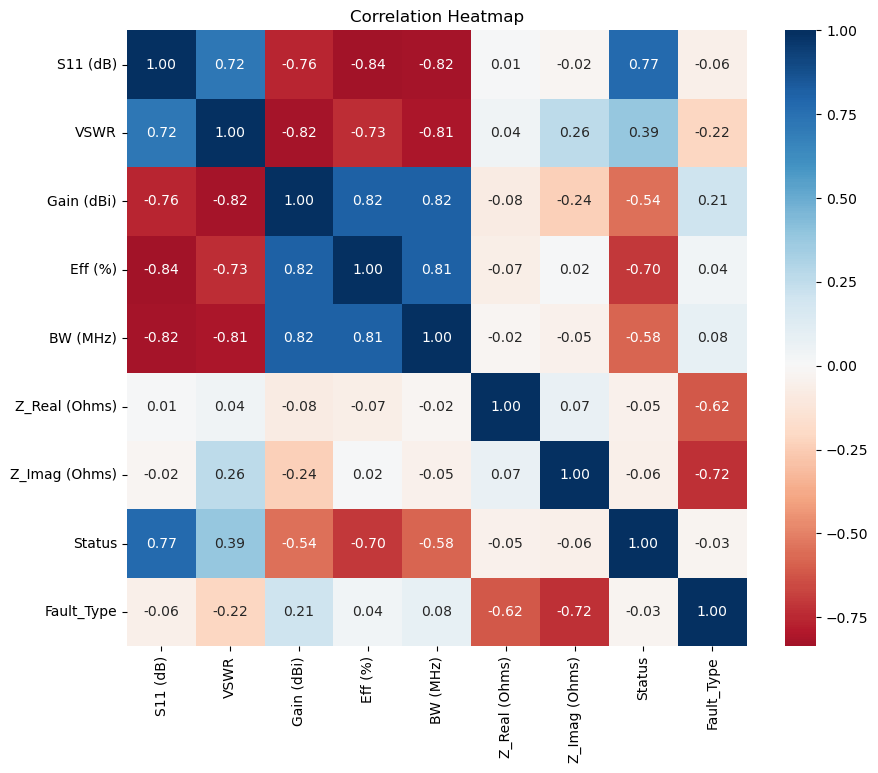

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

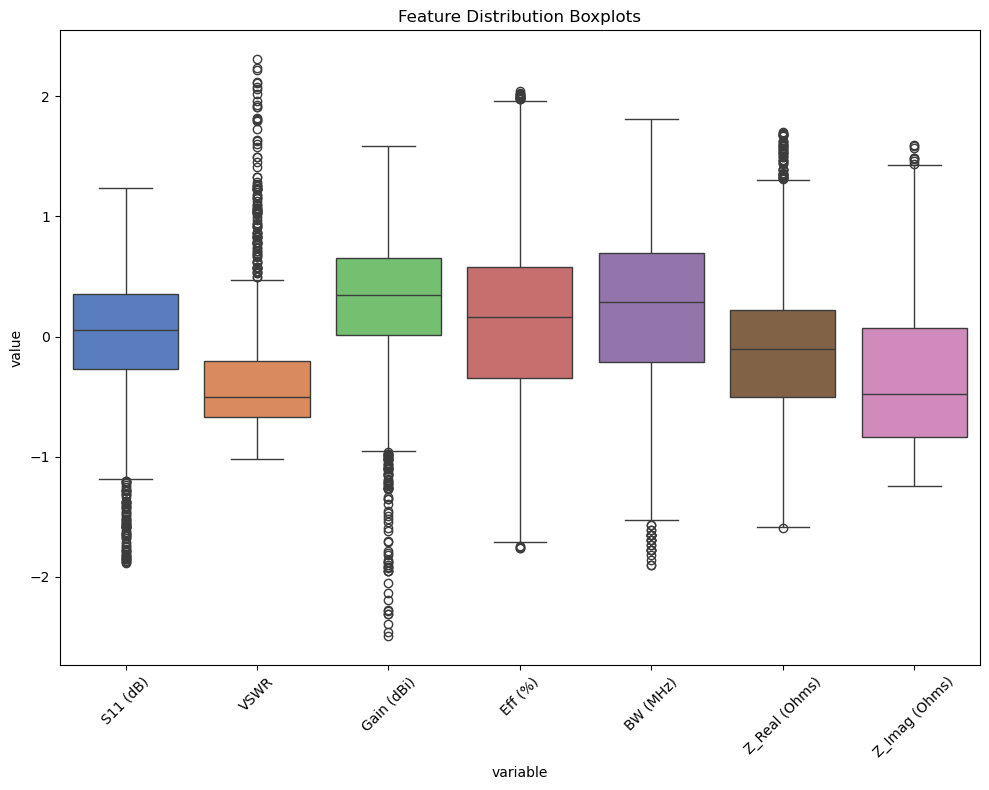

In [8]:
# Feature Distribution Boxplots (Fixed for FutureWarning)
plt.figure(figsize=(10, 8))
df_melted = df_cleaned.melt(id_vars='Fault_Type', value_vars=features)
sns.boxplot(data=df_melted, x='variable', y='value', hue='variable', palette='muted', legend=False)
plt.xticks(rotation=45)
plt.title('Feature Distribution Boxplots')
plt.tight_layout()
plt.show()

## Segmentation & Clustering

C:\Users\chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\chara\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

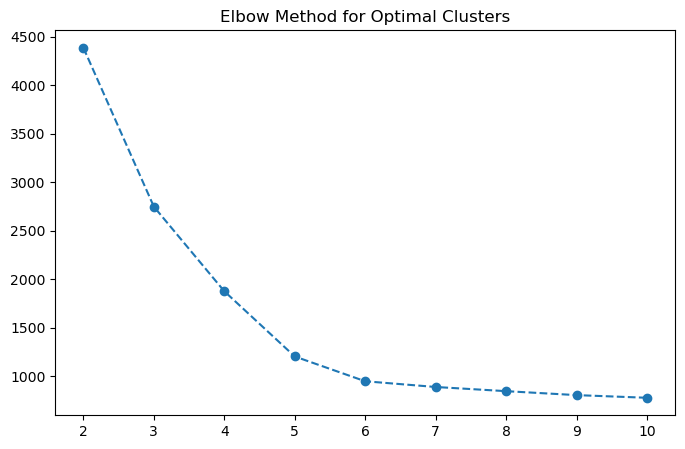

In [9]:
# Scaling features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cleaned[features])

# Elbow Method to find optimal k
inertia = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.savefig('elbow_method.png')

# Applying K-Means
# Applying K-Means
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
df_cleaned['Cluster'] = kmeans_final.fit_predict(X_scaled)

**Insights:**
The Elbow Method indicates that $k=6$ is an optimal point, which aligns perfectly with the 6 known fault categories. This confirms that the physical faults create distinct clusters in the feature space.

## Model Training & Evaluation

                 Model  Accuracy  Precision    Recall  F1-Score
1        Random Forest  1.000000   1.000000  1.000000  1.000000
2                  SVM  0.996785   0.996827  0.996785  0.996784
3    Gradient Boosting  0.996785   0.996827  0.996785  0.996784
0  Logistic Regression  0.993569   0.993736  0.993569  0.993568


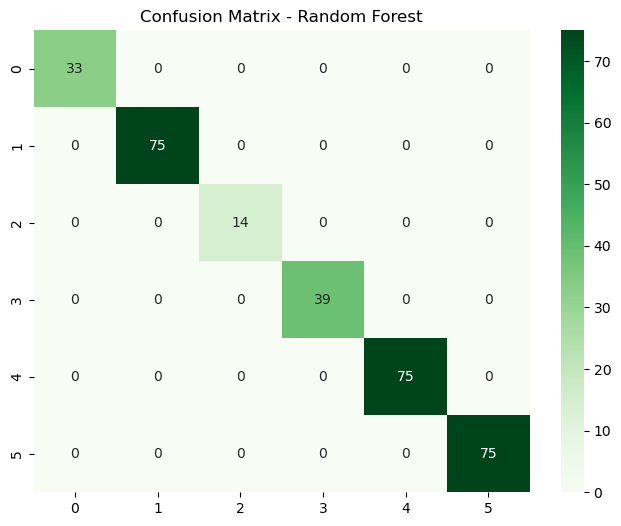

In [10]:
# Data Split
X = df_cleaned[features]
y = df_cleaned['Fault_Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score": f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print(results_df)

# Confusion Matrix for Best Model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig('best_model_confusion_matrix.png')